### 자세 추정

In [1]:
import cv2
import numpy as np
from PIL import Image

def show(image):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return Image.fromarray(rgb)

In [2]:
from ultralytics import YOLO
model = YOLO('yolo11n-pose.pt')

In [4]:
import cv2 as cv
img = cv.imread('../data/bus_stop.jpg')

In [5]:
# 자세 추정
results = model(img)


0: 448x640 5 persons, 49.1ms
Speed: 1.7ms preprocess, 49.1ms inference, 11.7ms postprocess per image at shape (1, 3, 448, 640)


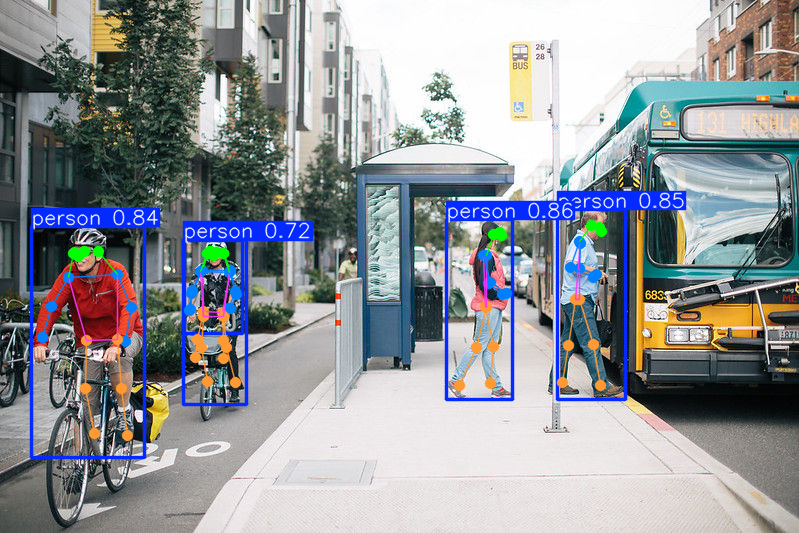

In [6]:
show(results[0].plot())

In [7]:
# 키포인트 (Keypoints)
keypoint_names = [                                              
    "Nose", "Left Eye", "Right Eye", "Left Ear", "Right Ear",
    "Left Shoulder", "Right Shoulder", "Left Elbow", "Right Elbow",
    "Left Wrist", "Right Wrist", "Left Hip", "Right Hip",
    "Left Knee", "Right Knee", "Left Ankle", "Right Ankle"]

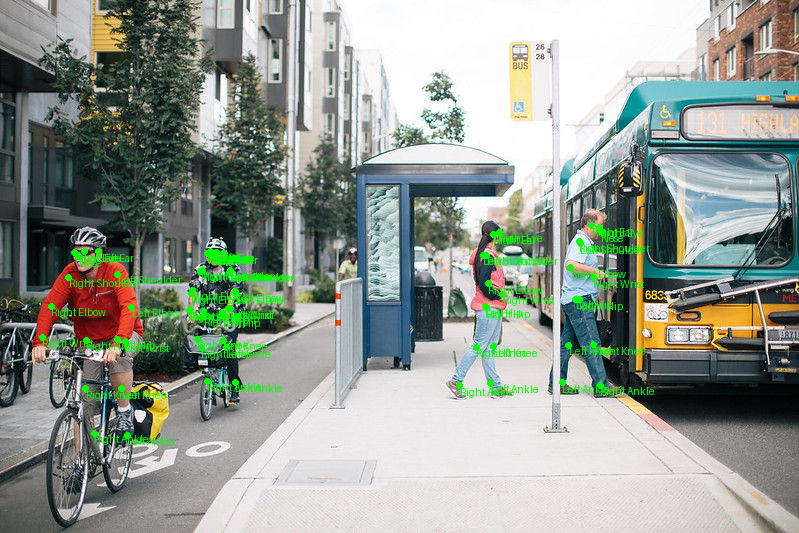

In [8]:
from PIL import Image, ImageDraw, ImageFont

# 글꼴 설정: 같은 폴더에 ttf 글꼴 파일이 있어야 함. 없으면 기본 글꼴 사용.
try:
    font = ImageFont.truetype("NanumGothic.ttf", 20)
except IOError:
    font = ImageFont.load_default()

result = results[0]
kpts = result.keypoints.data.cpu().numpy() # 사람별, 키포인트별, 좌표
img_bbox = Image.fromarray(cv.cvtColor(img, cv.COLOR_BGR2RGB))
draw = ImageDraw.Draw(img_bbox)

for kpt in kpts:
    for j in range(len(kpt)): # 17개 키포인트에 대해
        x, y, conf = kpt[j]
        if conf > 0.5:
            draw.circle((x, y), radius=3, fill="#00FF00") # 원
            draw.text((x, y), f'{keypoint_names[j]}', font=font, fill="#00FF00") # 키포인트 이름

img_bbox

In [9]:
kpts

array([[[     501.18,      235.72,     0.44007],
        [     498.53,      231.74,    0.054609],
        [     499.39,      232.04,     0.60686],
        [     487.02,      234.04,    0.026975],
        [      493.7,       234.2,     0.88894],
        [     483.37,      255.14,     0.87302],
        [      486.7,      255.37,     0.99297],
        [      490.6,      282.46,     0.35281],
        [     488.29,      283.68,      0.9875],
        [     506.28,      293.58,      0.3676],
        [     502.98,      294.13,     0.95385],
        [     485.27,      306.68,     0.98576],
        [     486.08,      307.61,     0.99692],
        [     493.48,      346.67,     0.98217],
        [     476.42,      347.24,     0.99653],
        [      490.7,      383.18,     0.97284],
        [     459.94,      385.94,     0.99172]],

       [[     601.16,      231.52,     0.64028],
        [     601.04,      227.74,     0.14707],
        [     599.76,      227.09,     0.72273],
        [     590.